# Base Master de Clientes

Objetivo: cruzar o cadastro de clientes (`PBI_Clientes`) com o histórico de pedidos (`PBI_DESEMPENHO_MATERIAL`) para:

- Saber quais clientes da Central ETO realmente compraram desde 2023
- Obter a data de última compra de cada cliente
- Inferir churn por recência (mais confiável que o STATUS do sistema)
- Criar o `df_master` — tabela consolidada para modelagem

In [50]:
import sys
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path(r"C:\Users\carva\central_eto")
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from src import db

print("Working directory:", os.getcwd())
print("Python:", sys.executable)

Working directory: C:\Users\carva\central_eto
Python: c:\Users\carva\central_eto\.venv\Scripts\python.exe


## 1. Carregar Base Enriquecida

Query que faz o JOIN entre clientes e pedidos diretamente no banco.

In [51]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)  # suprime aviso do SQLAlchemy

sql = Path("queries/base_clientes_enriquecida.sql").read_text()

df_enriquecida = db.get_data(sql)

# Converter datas
df_enriquecida["primeira_compra"] = pd.to_datetime(df_enriquecida["primeira_compra"], errors="coerce")
df_enriquecida["ultima_compra"]   = pd.to_datetime(df_enriquecida["ultima_compra"],   errors="coerce")

print(df_enriquecida.shape)
df_enriquecida.head()

(1133, 14)


,CODIGO,NOME,CLASSE,ATIVIDADE,UFENTREGA,CIDADEENTREGA,CONDICAOPAGAMENTO,status_sistema,DIASINADIMPLENTE,primeira_compra,ultima_compra,total_pedidos,total_valor,meses_sem_compra
0,1,HOSPITAL RG LTDA ...,COM CONTRATO PRIVADO,HOSPITAL,MG,BELO HORIZONTE,14 DIAS,Ativo,30,2023-01-02,2026-03-18,2504,571028.64,0.0
1,2,CASA DE SAUDE E MATERNIDADE SANTA FE S.A. ...,SEM CONTRATO PRIVADO,HOSPITAL,MG,BELO HORIZONTE,14 DIAS,Inativo,0,NaT,NaT,0,0.00,NaN
2,3,SERVICO SOCIAL AUTONOMO ...,COM CONTRATO ORGAO PUBLICO,HOSPITAL,MG,Contagem,28 DIAS,Ativo,60,2023-01-03,2026-03-19,4031,1989264.60,0.0
3,4,PREMIER HOSPITAL DIA ...,COM CONTRATO PRIVADO,CLINICA,MG,BELO HORIZONTE,7 DIAS,Ativo,5,2023-01-03,2026-03-18,3784,576849.60,0.0
4,5,FUNDACAO EDUCACIONAL LUCAS MACHADO FELUMA ...,COM CONTRATO PRIVADO,HOSPITAL,MG,BELO HORIZONTE,14 DIAS,Inativo,10,2023-01-02,2024-10-02,616,142715.92,17.0


In [52]:
df_enriquecida.info()

<class 'pandas.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CODIGO             1133 non-null   int64         
 1   NOME               1133 non-null   str           
 2   CLASSE             1133 non-null   str           
 3   ATIVIDADE          1051 non-null   str           
 4   UFENTREGA          1133 non-null   str           
 5   CIDADEENTREGA      1133 non-null   str           
 6   CONDICAOPAGAMENTO  1088 non-null   str           
 7   status_sistema     1133 non-null   str           
 8   DIASINADIMPLENTE   1133 non-null   int64         
 9   primeira_compra    746 non-null    datetime64[us]
 10  ultima_compra      746 non-null    datetime64[us]
 11  total_pedidos      1133 non-null   int64         
 12  total_valor        1133 non-null   float64       
 13  meses_sem_compra   746 non-null    float64       
dtypes: datetime64[us](2

## 2. Categoria de Volume por Cliente

Classifica cada cliente pela **cadência média de compra** (pedidos/mês), replicando a lógica descoberta em `01_pedidos_eda`. Permite thresholds de churn personalizados por segmento em vez de um valor fixo único.

In [53]:
import re
from src.features import make_cliente_mes

# Pedidos brutos (mesmo dado do notebook 01)
sql_raw = Path("queries/base_pedidos.sql").read_text()
sql_pedidos = re.split(r"-- QUERIE:", sql_raw)[1]         # pega o 1º bloco
sql_pedidos = sql_pedidos.strip().split("\n", 1)[1]       # remove a linha de nome

df_pedidos = db.get_data(sql_pedidos)

cliente_mes = make_cliente_mes(df_pedidos, inicio="2023-01-01", neg_policy="clip0")

# Mesma lógica de classificação do notebook 01
def classificar_volume(x):
    if x <= 2:   return "baixo"
    elif x <= 5: return "medio"
    else:        return "alto"

cliente_mes["categoria_volume"] = cliente_mes["total_pedidos"].apply(classificar_volume)

# Agrega para 1 linha por cliente: categoria predominante (moda)
df_categoria = (
    cliente_mes
    .groupby("CLIENTE")["categoria_volume"]
    .agg(lambda x: x.mode()[0])
    .reset_index()
    .rename(columns={"CLIENTE": "CODIGO"})
)

print(f"Clientes categorizados: {len(df_categoria)}")
print(df_categoria["categoria_volume"].value_counts())

Clientes categorizados: 746
categoria_volume
baixo    611
alto      80
medio     55
Name: count, dtype: int64


## 2. Cobertura: quais clientes compraram desde 2023?

In [54]:
from IPython.display import display

tem_pedido = df_enriquecida["ultima_compra"].notna()

resumo = pd.DataFrame({
    "Grupo": ["Com pedido desde 2023", "Sem pedido desde 2023", "Total cadastrado"],
    "Qtd":   [tem_pedido.sum(), (~tem_pedido).sum(), len(df_enriquecida)],
    "Pct":   [f"{tem_pedido.mean():.1%}", f"{(~tem_pedido).mean():.1%}", "100%"]
})
display(resumo.set_index("Grupo"))

print("\nStatus no sistema — clientes SEM pedido desde 2023:")
display(
    df_enriquecida[~tem_pedido]["status_sistema"]
    .value_counts()
    .rename_axis("status_sistema")
    .reset_index(name="qtd")
    .set_index("status_sistema")
)

,Qtd,Pct
Grupo,,
Com pedido desde 2023,746,65.8%
Sem pedido desde 2023,387,34.2%
Total cadastrado,1133,100%



Status no sistema — clientes SEM pedido desde 2023:


,qtd
status_sistema,
Inativo,319
Ativo,68


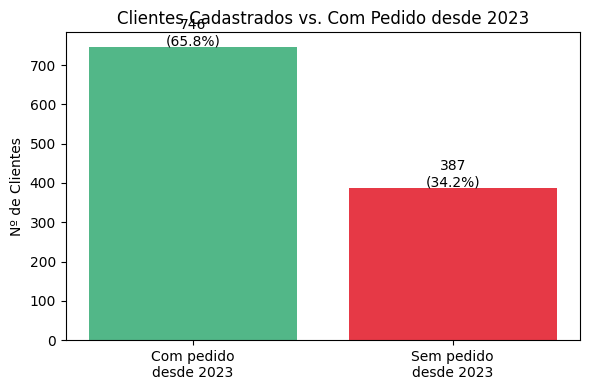

In [55]:
# Visualização da cobertura
labels = ["Com pedido\ndesde 2023", "Sem pedido\ndesde 2023"]
valores = [tem_pedido.sum(), (~tem_pedido).sum()]
cores = ["#52b788", "#e63946"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, valores, color=cores)
ax.set_title("Clientes Cadastrados vs. Com Pedido desde 2023")
ax.set_ylabel("Nº de Clientes")

for bar, val, pct in zip(bars, valores, [v/len(df_enriquecida) for v in valores]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{val}\n({pct:.1%})", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## 3. Análise de Recência (clientes com pedido)

In [56]:
df_com_pedido = df_enriquecida[tem_pedido].copy()

display(
    df_com_pedido["meses_sem_compra"]
    .describe()
    .rename("meses_sem_compra")
    .to_frame()
    .round(1)
)

,meses_sem_compra
count,746.0
mean,8.6
std,10.3
min,0.0
25%,0.0
50%,4.0
75%,14.0
max,38.0


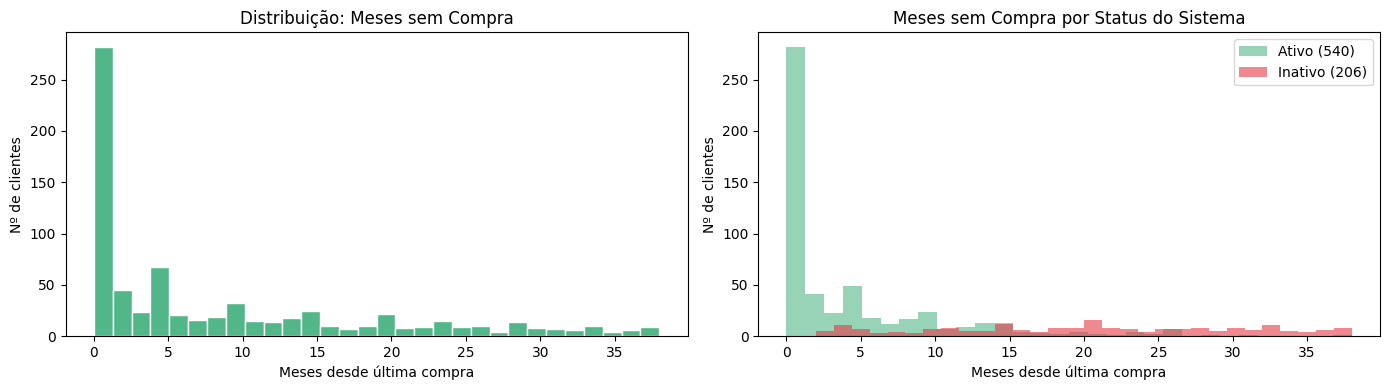

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma geral
axes[0].hist(df_com_pedido["meses_sem_compra"], bins=30, color="#52b788", edgecolor="white")
axes[0].set_title("Distribuição: Meses sem Compra")
axes[0].set_xlabel("Meses desde última compra")
axes[0].set_ylabel("Nº de clientes")

# Por status do sistema
for status, color in [("Ativo", "#52b788"), ("Inativo", "#e63946")]:
    subset = df_com_pedido[df_com_pedido["status_sistema"] == status]["meses_sem_compra"]
    axes[1].hist(subset, bins=30, alpha=0.6, label=f"{status} ({len(subset)})", color=color)

axes[1].set_title("Meses sem Compra por Status do Sistema")
axes[1].set_xlabel("Meses desde última compra")
axes[1].set_ylabel("Nº de clientes")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Reconciliação: STATUS do sistema vs. Recência Real

O STATUS administrativo pode estar defasado. Vamos comparar com o comportamento real de compra.

- **Falso negativo:** cliente marcado como *Ativo* no sistema, mas sem compra recente → churn silencioso
- **Falso positivo:** cliente marcado como *Inativo*, mas comprou recentemente → status desatualizado

In [58]:
THRESHOLD_CHURN = {"alto": 2, "medio": 3, "baixo": 6}

df_com_pedido = df_com_pedido.merge(df_categoria, on="CODIGO", how="left")
df_com_pedido["categoria_volume"] = df_com_pedido["categoria_volume"].fillna("baixo")
df_com_pedido["threshold_churn"]  = df_com_pedido["categoria_volume"].map(THRESHOLD_CHURN)
df_com_pedido["churn_recencia"]   = (df_com_pedido["meses_sem_compra"] >= df_com_pedido["threshold_churn"]).astype(int)
df_com_pedido["churn_sistema"]    = (df_com_pedido["status_sistema"] == "Inativo").astype(int)

concordancia = pd.crosstab(
    df_com_pedido["churn_sistema"].map({0: "Ativo (sistema)", 1: "Inativo (sistema)"}),
    df_com_pedido["churn_recencia"].map({0: "Ativo (recência)", 1: "Inativo (recência)"}),
    margins=True
)

print("Concordância: STATUS sistema vs. Recência (threshold dinâmico)")
display(concordancia)

falsos_neg = df_com_pedido[(df_com_pedido["churn_sistema"] == 0) & (df_com_pedido["churn_recencia"] == 1)]
falsos_pos = df_com_pedido[(df_com_pedido["churn_sistema"] == 1) & (df_com_pedido["churn_recencia"] == 0)]

display(pd.DataFrame({
    "Caso": [
        "Churn silencioso (ativo no sistema, churned na prática)",
        "Status desatualizado (inativo no sistema, ativo na prática)"
    ],
    "Qtd":    [len(falsos_neg), len(falsos_pos)],
    "% base": [f"{len(falsos_neg)/len(df_com_pedido):.1%}", f"{len(falsos_pos)/len(df_com_pedido):.1%}"]
}).set_index("Caso"))

Concordância: STATUS sistema vs. Recência (threshold dinâmico)


churn_recencia,Ativo (recência),Inativo (recência),All
churn_sistema,,,
Ativo (sistema),392,148,540
Inativo (sistema),18,188,206
All,410,336,746


,Qtd,% base
Caso,,
"Churn silencioso (ativo no sistema, churned na prática)",148,19.8%
"Status desatualizado (inativo no sistema, ativo na prática)",18,2.4%


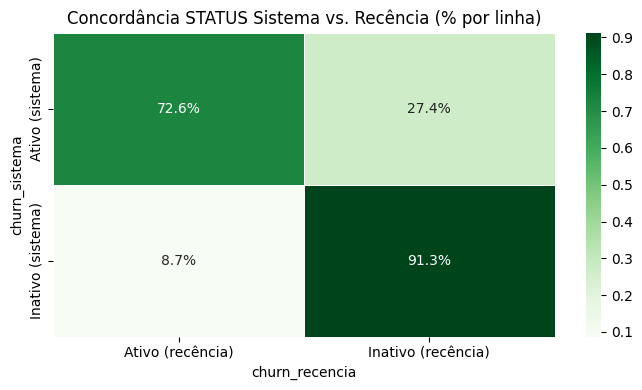

In [59]:
# Heatmap da matriz de concordância
concordancia_pct = pd.crosstab(
    df_com_pedido["churn_sistema"].map({0: "Ativo (sistema)", 1: "Inativo (sistema)"}),
    df_com_pedido["churn_recencia"].map({0: "Ativo (recência)", 1: "Inativo (recência)"}),
    normalize="index"
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(concordancia_pct, annot=True, fmt=".1%", cmap="Greens", ax=ax, linewidths=0.5)
ax.set_title("Concordância STATUS Sistema vs. Recência (% por linha)")
plt.tight_layout()
plt.show()

## 5. df_master — Tabela Final

Tabela consolidada com features de perfil + comportamentais + label de churn.

Critérios:
- Apenas clientes com ≥ 1 pedido desde 2023
- Label `churn_recencia` baseado em recência comportamental

In [60]:
df_master = df_com_pedido[[
    "CODIGO", "NOME", "CLASSE", "ATIVIDADE", "UFENTREGA",
    "CONDICAOPAGAMENTO", "DIASINADIMPLENTE",
    "primeira_compra", "ultima_compra",
    "total_pedidos", "total_valor",
    "meses_sem_compra", "categoria_volume",
    "status_sistema", "churn_recencia"
]].copy()

print(f"df_master — {len(df_master)} clientes | taxa de churn: {df_master['churn_recencia'].mean():.1%}")

display(
    df_master["churn_recencia"]
    .value_counts()
    .rename({0: "Ativo", 1: "Churned"})
    .rename_axis("label")
    .reset_index(name="qtd")
    .assign(pct=lambda x: (x["qtd"] / x["qtd"].sum()).map("{:.1%}".format))
    .set_index("label")
)

display(
    df_master.groupby("categoria_volume")["churn_recencia"]
    .agg(churned="sum", total="count", taxa="mean")
    .assign(taxa=lambda x: x["taxa"].map("{:.1%}".format))
)

df_master.head(10)

df_master — 746 clientes | taxa de churn: 45.0%


,qtd,pct
label,,
Ativo,410,55.0%
Churned,336,45.0%


,churned,total,taxa
categoria_volume,,,
alto,29,80,36.2%
baixo,294,611,48.1%
medio,13,55,23.6%


,CODIGO,NOME,CLASSE,ATIVIDADE,UFENTREGA,CONDICAOPAGAMENTO,DIASINADIMPLENTE,primeira_compra,ultima_compra,total_pedidos,total_valor,meses_sem_compra,categoria_volume,status_sistema,churn_recencia
0,1,HOSPITAL RG LTDA ...,COM CONTRATO PRIVADO,HOSPITAL,MG,14 DIAS,30,2023-01-02,2026-03-18,2504,571028.64,0.0,alto,Ativo,0
1,3,SERVICO SOCIAL AUTONOMO ...,COM CONTRATO ORGAO PUBLICO,HOSPITAL,MG,28 DIAS,60,2023-01-03,2026-03-19,4031,1989264.60,0.0,alto,Ativo,0
2,4,PREMIER HOSPITAL DIA ...,COM CONTRATO PRIVADO,CLINICA,MG,7 DIAS,5,2023-01-03,2026-03-18,3784,576849.60,0.0,alto,Ativo,0
3,5,FUNDACAO EDUCACIONAL LUCAS MACHADO FELUMA ...,COM CONTRATO PRIVADO,HOSPITAL,MG,14 DIAS,10,2023-01-02,2024-10-02,616,142715.92,17.0,alto,Inativo,1
4,7,INSTITUTO DE CIRURG E GAST PROF JOSE G P COELH...,COM CONTRATO PRIVADO,HOSPITAL,MG,7 DIAS,30,2023-01-03,2023-04-11,82,16261.87,35.0,alto,Inativo,1
5,9,FUNDACAO HOSPITALAR SAO FRANCISCO DE ASSIS ...,COM CONTRATO PRIVADO,HOSPITAL,MG,7 DIAS,999,2023-01-11,2023-11-17,8,2964.63,28.0,baixo,Ativo,1
6,10,CLINICA DE CIR. PLASTICA DR. ALFONSO SEMPERTEG...,COM CONTRATO PRIVADO,CLINICA,MG,14 DIAS,999,2023-11-06,2026-03-11,338,62434.66,0.0,alto,Ativo,0
7,12,ASSOCIACAO EVANGELICA BENEFICENTE DE MINAS GER...,COM CONTRATO PRIVADO,HOSPITAL,MG,7 DIAS,5,2023-01-02,2026-03-19,737,147511.81,0.0,alto,Ativo,0
8,15,IRMANDADE N. S. DAS MERCES DE MONTES CLARO ...,COM CONTRATO PRIVADO,HOSPITAL,MG,7 DIAS,5,2023-01-17,2026-01-14,394,835701.46,2.0,alto,Inativo,1
9,21,ONCOBIO SERVICOS DE SAUDE SA ...,COM CONTRATO PRIVADO,CLINICA,MG,14 DIAS,30,2023-01-02,2023-07-19,307,80694.33,32.0,alto,Inativo,1


In [61]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 746 entries, 0 to 745
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CODIGO             746 non-null    int64         
 1   NOME               746 non-null    str           
 2   CLASSE             746 non-null    str           
 3   ATIVIDADE          706 non-null    str           
 4   UFENTREGA          746 non-null    str           
 5   CONDICAOPAGAMENTO  746 non-null    str           
 6   DIASINADIMPLENTE   746 non-null    int64         
 7   primeira_compra    746 non-null    datetime64[us]
 8   ultima_compra      746 non-null    datetime64[us]
 9   total_pedidos      746 non-null    int64         
 10  total_valor        746 non-null    float64       
 11  meses_sem_compra   746 non-null    float64       
 12  categoria_volume   746 non-null    str           
 13  status_sistema     746 non-null    str           
 14  churn_recencia     74

## 6. Validação do Threshold — Análise de Ressurreição

Quando um cliente fica ausente por N meses, qual a probabilidade de ele **voltar a comprar**?
Se a curva cai drasticamente no threshold definido, o critério é sólido.

In [ ]:
cm = cliente_mes.copy()
cm["ANO_MES"] = cm["ANO_MES"].dt.to_timestamp()
cm = cm.sort_values(["CLIENTE", "ANO_MES"]).reset_index(drop=True)
cm = (cm.drop(columns="categoria_volume")
        .merge(df_categoria, left_on="CLIENTE", right_on="CODIGO", how="left")
        .drop(columns="CODIGO"))
cm["categoria_volume"] = cm["categoria_volume"].fillna("baixo")

cm["prox_compra"] = cm.groupby("CLIENTE")["ANO_MES"].shift(-1)
ref = cm["ANO_MES"].max()

cm["gap"] = (
    (cm["prox_compra"].dt.year  - cm["ANO_MES"].dt.year)  * 12 +
    (cm["prox_compra"].dt.month - cm["ANO_MES"].dt.month)
)
mask_ult = cm["prox_compra"].isna()
cm.loc[mask_ult, "gap"] = (
    (ref.year  - cm.loc[mask_ult, "ANO_MES"].dt.year)  * 12 +
    (ref.month - cm.loc[mask_ult, "ANO_MES"].dt.month)
)
cm["retornou"] = cm["prox_compra"].notna()

rows = []
for g in range(1, 13):
    sub = cm[cm["gap"] >= g]
    rows.append({"ausencia_min_meses": g,
                 "episodios": len(sub),
                 "retornou": int(sub["retornou"].sum()),
                 "taxa_retorno": sub["retornou"].mean()})
df_retorno = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df_retorno["ausencia_min_meses"], df_retorno["taxa_retorno"],
             marker="o", color="#2d6a4f", linewidth=2)
for cat, thr in THRESHOLD_CHURN.items():
    axes[0].axvline(x=thr, linestyle="--", alpha=0.5, label=f"threshold {cat} ({thr}m)")
axes[0].set_title("Taxa de retorno por ausência mínima")
axes[0].set_xlabel("Meses de ausência mínima")
axes[0].set_ylabel("% que voltou a comprar")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for cat, color in [("alto", "#1b4332"), ("medio", "#52b788"), ("baixo", "#b7e4c7")]:
    sub_cat = cm[cm["categoria_volume"] == cat]
    rows_cat = []
    for g in range(1, 13):
        s = sub_cat[sub_cat["gap"] >= g]
        if len(s):
            rows_cat.append({"gap": g, "taxa": s["retornou"].mean()})
    if rows_cat:
        d = pd.DataFrame(rows_cat)
        axes[1].plot(d["gap"], d["taxa"], marker="o", label=cat, color=color, linewidth=2)
    axes[1].axvline(x=THRESHOLD_CHURN[cat], linestyle="--", color=color, alpha=0.5)

axes[1].set_title("Taxa de retorno por categoria de volume")
axes[1].set_xlabel("Meses de ausência mínima")
axes[1].set_ylabel("% que voltou a comprar")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

display(df_retorno.set_index("ausencia_min_meses").round(3))

## 7. Churn Silencioso — Quem São?

Clientes marcados como **Ativos** no sistema mas que não compram há mais que o threshold da sua categoria. Esse grupo representa risco invisível para o negócio.

In [ ]:
churn_silencioso = df_master[
    (df_master["status_sistema"] == "Ativo") &
    (df_master["churn_recencia"] == 1)
].copy()

print(f"Churn silencioso: {len(churn_silencioso)} clientes ({len(churn_silencioso)/len(df_master):.1%} da base)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

classe_dist = churn_silencioso["CLASSE"].value_counts()
axes[0].barh(classe_dist.index, classe_dist.values, color="#e63946")
axes[0].set_title("Por CLASSE")
axes[0].invert_yaxis()

cat_dist = churn_silencioso["categoria_volume"].value_counts().reindex(["alto","medio","baixo"])
axes[1].bar(cat_dist.index, cat_dist.values, color=["#1b4332","#52b788","#b7e4c7"])
axes[1].set_title("Por Categoria de Volume")

axes[2].hist(churn_silencioso["meses_sem_compra"], bins=20, color="#e63946", edgecolor="white")
axes[2].set_title("Meses sem compra")
axes[2].set_xlabel("meses")

plt.suptitle("Perfil do Churn Silencioso", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

display(
    churn_silencioso.groupby("categoria_volume").agg(
        qtd=("CODIGO", "count"),
        media_meses_sem_compra=("meses_sem_compra", "mean"),
        media_dias_inadimplente=("DIASINADIMPLENTE", "mean")
    ).round(1)
)

## 8. Inadimplência × Recência

Clientes que param de comprar também tendem a acumular dívidas? Um padrão forte indica que `DIASINADIMPLENTE` é uma feature preditiva de churn.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_churn = df_master["churn_recencia"].map({0: "Ativo", 1: "Churned"})

for label, color in [("Ativo", "#52b788"), ("Churned", "#e63946")]:
    mask = labels_churn == label
    axes[0].scatter(
        df_master.loc[mask, "meses_sem_compra"],
        df_master.loc[mask, "DIASINADIMPLENTE"].clip(upper=400),
        alpha=0.35, s=20, color=color, label=label
    )
axes[0].set_xlabel("Meses sem compra")
axes[0].set_ylabel("Dias inadimplente (cap 400)")
axes[0].set_title("Inadimplência × Recência")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

df_master.boxplot(column="DIASINADIMPLENTE", by="churn_recencia", ax=axes[1],
                  patch_artist=True,
                  boxprops=dict(facecolor="#b7e4c7"),
                  medianprops=dict(color="#1b4332", linewidth=2))
axes[1].set_xticklabels(["Ativo (0)", "Churned (1)"])
axes[1].set_title("Dias inadimplente por label de churn")
axes[1].set_xlabel("")
plt.suptitle("")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

display(
    df_master.groupby("churn_recencia")["DIASINADIMPLENTE"]
    .agg(["mean","median","max","count"])
    .rename(index={0:"Ativo", 1:"Churned"})
    .rename(columns={"mean":"média","median":"mediana","max":"máximo","count":"n"})
    .round(1)
)

## 9. Heatmap: CLASSE × Categoria de Volume

Taxa de churn em cada combinação de segmento. Mostra onde o risco está concentrado.

In [ ]:
pivot = df_master.pivot_table(
    values="churn_recencia", index="CLASSE",
    columns="categoria_volume", aggfunc="mean"
)[["alto", "medio", "baixo"]]

pivot_n = df_master.pivot_table(
    values="churn_recencia", index="CLASSE",
    columns="categoria_volume", aggfunc="count"
)[["alto", "medio", "baixo"]]

annot = (pivot.map(lambda x: f"{x:.0%}" if pd.notna(x) else "--") +
         "\n(" + pivot_n.map(lambda x: str(int(x)) if pd.notna(x) else "") + ")")

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot, annot=annot, fmt="", cmap="RdYlGn_r",
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Taxa de Churn"})
ax.set_title("Taxa de Churn por CLASSE x Categoria de Volume\n(% churned | n clientes)")
ax.set_xlabel("Categoria de Volume")
ax.set_ylabel("CLASSE")
plt.tight_layout()
plt.show()

## 10. Timeline da Última Compra

Quando os clientes pararam de comprar? Picos concentrados em alguma época indicam eventos externos (sazonalidade, concorrência, problemas operacionais).

In [ ]:
df_timeline = df_master.copy()
df_timeline["ano_mes_ultima"] = df_timeline["ultima_compra"].dt.to_period("M")

contagem = (
    df_timeline.groupby(["ano_mes_ultima", "churn_recencia"])
    .size().reset_index(name="n")
)
contagem["ano_mes_ultima"] = contagem["ano_mes_ultima"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
for label, color in [(0, "#52b788"), (1, "#e63946")]:
    d = contagem[contagem["churn_recencia"] == label]
    ax.plot(d["ano_mes_ultima"], d["n"], color=color,
            label="Ativo" if label == 0 else "Churned", linewidth=2)
    ax.fill_between(d["ano_mes_ultima"], d["n"], alpha=0.15, color=color)

ax.set_title("Nº de clientes por mês da última compra")
ax.set_xlabel("Mês da última compra")
ax.set_ylabel("Nº de clientes")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

top_churn = (
    df_timeline[df_timeline["churn_recencia"] == 1]
    .groupby("ano_mes_ultima").size()
    .sort_values(ascending=False).head(5)
    .rename("churned_naquele_mes").reset_index()
)
top_churn["ano_mes_ultima"] = top_churn["ano_mes_ultima"].astype(str)
display(top_churn.set_index("ano_mes_ultima"))